# Steam EDA
Exploratory analysis for the Steam recommendation dataset.

In [8]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.data_loader import (
    build_interaction_matrices,
    filter_recommendations,
    load_steam_data,
    print_dataset_statistics,
)

sns.set_theme(style='whitegrid')

In [11]:
DATA_DIR = ROOT / 'data'
recommendations, games, users = load_steam_data(DATA_DIR)

print('Raw recommendations rows:', len(recommendations))
print('Games rows:', len(games))
print('Users rows:', len(users))

filtered = filter_recommendations(recommendations, min_user_reviews=5, min_game_reviews=50)
interaction_data = build_interaction_matrices(filtered)

print_dataset_statistics(interaction_data.binary_matrix, title='Binary interaction matrix')
print_dataset_statistics(interaction_data.hours_matrix, title='Hours interaction matrix')

Raw recommendations rows: 41154794
Games rows: 50872
Users rows: 14306064
Filtered interactions: rows=22,073,781, users=1,910,788, games=15,307
Binary interaction matrix:
  Users (m): 1,910,788
  Games (n): 15,307
  Interactions (nnz): 22,073,761
  Sparsity: 0.999245
Hours interaction matrix:
  Users (m): 1,910,788
  Games (n): 15,307
  Interactions (nnz): 22,073,761
  Sparsity: 0.999245


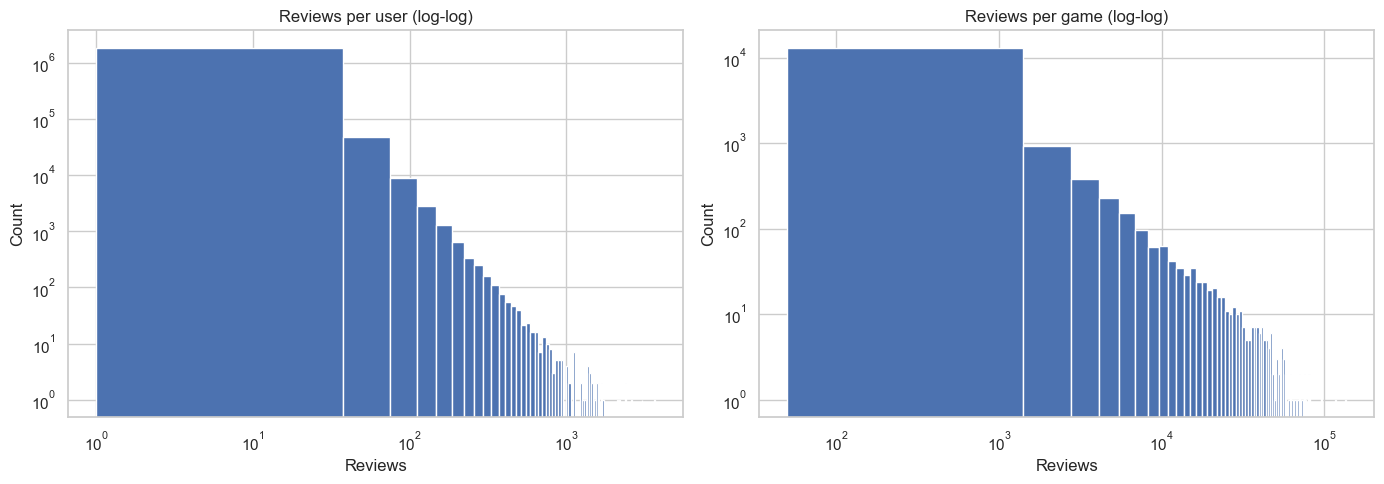

In [12]:
reviews_per_user = filtered.groupby('user_id').size()
reviews_per_game = filtered.groupby('app_id').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(reviews_per_user, bins=100)
axes[0].set_yscale('log')
axes[0].set_xscale('log')
axes[0].set_title('Reviews per user (log-log)')
axes[0].set_xlabel('Reviews')
axes[0].set_ylabel('Count')

axes[1].hist(reviews_per_game, bins=100)
axes[1].set_yscale('log')
axes[1].set_xscale('log')
axes[1].set_title('Reviews per game (log-log)')
axes[1].set_xlabel('Reviews')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

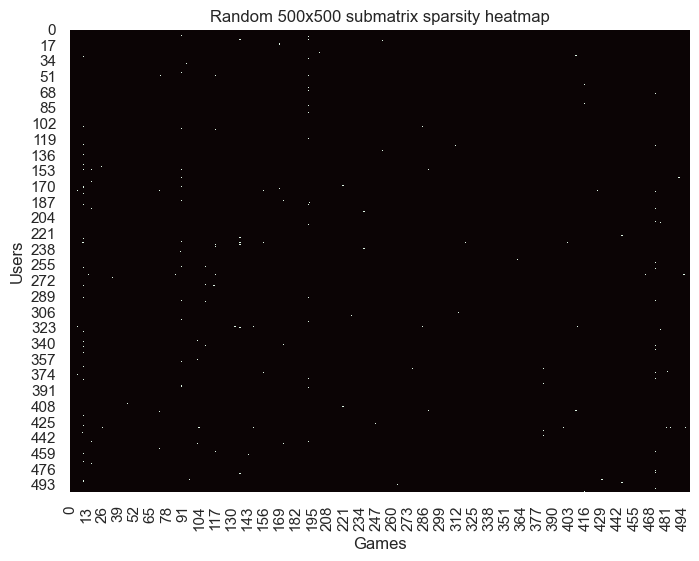

In [13]:
binary_matrix = interaction_data.binary_matrix.tocsr()
m, n = binary_matrix.shape

rng = np.random.default_rng(42)
sample_users = rng.choice(m, size=min(500, m), replace=False)
sample_games = rng.choice(n, size=min(500, n), replace=False)

submatrix = binary_matrix[sample_users][:, sample_games].toarray()

plt.figure(figsize=(8, 6))
sns.heatmap(submatrix, cmap='mako', cbar=False)
plt.title('Random 500x500 submatrix sparsity heatmap')
plt.xlabel('Games')
plt.ylabel('Users')
plt.show()

In [15]:
output_path = DATA_DIR / 'interactions_filtered.csv'
filtered.to_csv(output_path, index=False)
print(f'Saved filtered interactions to: {output_path}')

Saved filtered interactions to: /Users/anselgunther/Desktop/GitHub/steam-game-recommender/data/interactions_filtered.csv
